# Fig 1.3 — Reiaan's Room Floor Plan (Ganita Manjari, Class 9, Ch. 1)

A rich, interactive recreation of the NCERT figure **Fig 1.3**. Reiaan's room is a rectangle **OABC** with **O(0,0)**, **A(0,6)**, **B(12,6)**, **C(12,0)** (12 ft × 6 ft).

This notebook renders it in two ways:
1. **Rich static figure** — hatched materials, wall shadows, door-swing arcs, dimension arrows, a scale bar and a north arrow.
2. **Interactive figure** — ipywidgets sliders/toggles to highlight each textbook question (Q1–Q4), and to toggle grid, labels, dimensions and furniture.

*Each unit on the axes = 1 foot; the origin O is the corner of the room. Doors, window, bed, study table and wardrobe are labelled.*

## 1. Setup

Run the next cell once. It imports the plotting libraries and defines the colour palette and the reusable plotting helpers we will use to draw the room.

In [1]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc

# ---------- Colour palette (match the original SVG art) ----------
BLUE   = '#2563EB'; RED  = '#DC2626'; GREEN = '#15803D'; AMBER = '#B45309'
CYAN   = '#0E7490'; PURPLE = '#7C3AED'; WOOD = '#92400E'
WALL   = '#0F172A'; AXIS = '#334155'; SLATE = '#64748B'; GRAY = '#94A3B8'
FLOOR  = '#FFF7ED'; TILE = '#FDE6C8'

SERIF = 'DejaVu Serif'

print('imports OK')
%matplotlib inline

imports OK


## 2. The rich static rendering

Here is the **static** `draw_room()` function. It draws the floor plan procedurally so every element (wall, door swing, window, furniture, dimension rulers) appears as real vector geometry.

Parameters:
- `w, h` — room width / height in feet (default 12 × 6).
- `show_*` — toggles for grid, labels, dimensions, furniture.
- `emph` — which textbook question to highlight (None flashes all).

In [2]:
def draw_room(ax, w=12.0, h=6.0, show_grid=True, show_furniture=True,
              show_labels=True, show_dims=True, emph=None):
    """Draw Reiaan's 12×6 ft room on an already-configured Axes."""
    ax.set_facecolor('#FEFCF9')

    # ---- floor interior (light) + tile grid ----
    ax.add_patch(Rectangle((0, 0), w, h, facecolor=FLOOR, edgecolor='none', zorder=1))
    if show_grid:
        for i in range(1, int(w)):
            ax.plot([i, i], [0, h], color=TILE, lw=0.6, zorder=1.5)
        for j in range(1, int(h)):
            ax.plot([0, w], [j, j], color=TILE, lw=0.6, zorder=1.5)

    # ---- scale positions as fractions of room dims so sliders stay coherent ----
    door_x0, door_x1 = 8.5/12*w, 11.5/12*w   # room door on bottom wall
    bath_y0, bath_y1 = 1.5/6*h, 4.0/6*h      # bathroom door on left wall
    win_x0, win_x1   = 2/12*w, 5/12*w        # window on top wall
    leaf = 3.0                               # door leaf length in feet

    # ---- walls (thick, with a soft outer shadow) ----
    for (x1, y1), (x2, y2) in [((0,0),(w,0)), ((0,h),(w,h)), ((0,0),(0,h)), ((w,0),(w,h))]:
        ax.plot([x1, x2], [y1, y2], color=GRAY, lw=9, solid_capstyle='round',
                alpha=0.35, zorder=2)

    def wall(x1, y1, x2, y2):
        ax.plot([x1, x2], [y1, y2], color=WALL, lw=5, solid_capstyle='round', zorder=4)

    # bottom wall with a gap for the room door
    wall(0, 0, door_x0, 0); wall(door_x1, 0, w, 0)
    wall(0, h, w, h)                      # top wall
    wall(0, 0, 0, bath_y0); wall(0, bath_y1, 0, h)   # left wall (bathroom door gap)
    wall(w, 0, w, h)                      # right wall

    # ---- room door D1-R1 (3 ft, dashed) with swing arc ----
    ax.plot([door_x0, door_x1], [0, 0], color='white', lw=9, zorder=3)
    ax.plot([door_x0, door_x1], [0, 0], color=AMBER, lw=3.5, ls=(0, (7, 5)), zorder=4)
    # door leaf (hinge at D1) swings into the room at 45°
    ax.plot([door_x0, door_x0 + leaf*math.cos(math.radians(45))],
            [0, leaf*math.sin(math.radians(45))], color=AMBER, lw=3, zorder=4)
    ax.add_patch(Arc((door_x0, 0), 2*leaf, 2*leaf, theta1=0, theta2=45,
                     color=AMBER, lw=1.5, ls=(0, (5, 4)), zorder=4))
    if show_labels:
        ax.text((door_x0 + door_x1)/2, -0.6, 'Room door (3 ft)', color=AMBER,
                ha='center', fontsize=9, fontweight='bold', zorder=6)

    # ---- bathroom door B1-B2 (2.5 ft) on the left wall ----
    ax.plot([0, 0], [bath_y0, bath_y1], color=GREEN, lw=3.5, ls=(0, (7, 5)), zorder=4)
    # leaf (hinge at top B2) swings into the room
    ax.plot([0, 1.7], [bath_y1, bath_y1], color=GREEN, lw=3, zorder=4)
    ax.add_patch(Arc((0, bath_y1), 3.4, 3.4, theta1=0, theta2=56,
                     color=GREEN, lw=1.5, ls=(0, (5, 4)), zorder=4))
    if show_labels:
        ax.text(-0.9, (bath_y0 + bath_y1)/2, 'Bathroom door (2.5 ft)', color=GREEN,
                ha='right', va='center', fontsize=9, fontweight='bold', zorder=6)

    # ---- window on the top wall ----
    ax.plot([win_x0, win_x1], [h, h], color=CYAN, lw=6, zorder=4)
    if show_labels:
        ax.text((win_x0 + win_x1)/2, h + 0.45, 'Window', color=CYAN,
                ha='center', fontsize=9, fontweight='bold', zorder=6)

    # ---- furniture ----
    if show_furniture:
        # study table (3x2 ft) near the room door
        ax.add_patch(Rectangle((8/12*w, 2/6*h), 3/12*w, 2/6*h, fc='#FDE68A', ec=WOOD,
                               lw=2, zorder=5))
        ax.text(9.5/12*w, 3/6*h, 'Study table\n3 ft × 2 ft', ha='center', va='center',
                color=WOOD, fontsize=8.5, fontweight='bold', zorder=6)
        # bed (6 x 2.5) along top wall
        ax.add_patch(Rectangle((1/12*w, 3.5/6*h), 6/12*w, 2.5/6*h, fc='#DBEAFE', ec=BLUE,
                               lw=2, zorder=3.1))
        ax.plot([1/12*w, 1/12*w+6/12*w], [(3.5+1.25)/6*h]*2, color='#93C5FD', lw=1.2, zorder=3.4)
        ax.text(4/12*w, 4.25/6*h, 'Bed', ha='center', va='center', color='#1E40AF',
                fontsize=9, fontweight='bold', zorder=6)
        # wardrobe (2x1.2 ft) bottom-left
        ax.add_patch(Rectangle((0.2/12*w, 0), 2/12*w, 1.2/6*h, fc='#E9D5FF', ec=PURPLE,
                               lw=2, zorder=3.5))
        ax.plot([1/12*w, 1/12*w], [0, 1.2/6*h], color='#C4B5FD', lw=1.2, zorder=3.6)
        ax.text(1.2/12*w, 0.6/6*h, 'Wardrobe', ha='center', va='center', color='#5B21B6',
                fontsize=8.5, fontweight='bold', zorder=6)

    # ---- corners ----
    if show_labels:
        corners = [(0, 0, 'O (0,0)',   'right', (0.15, 0.1)),
                   (0, h, 'A (0,6)',   'left', (0.15, -0.3)),
                   (w, h, 'B (12,6)',  'right', (-0.35, -0.3)),
                   (w, 0, 'C (12,0)',  'right', (-0.5, 0.1))]
        for x, y, txt, ha, off in corners:
            ax.plot(x, y, 'o', color=BLUE, ms=5, zorder=6)
            ax.text(x + off[0], y + off[1], txt, color=BLUE, ha=ha, va='center',
                    fontsize=9, fontweight='bold', zorder=6, fontfamily='serif')

    # ---- rulers on x and y axes + overall dimensions ----
    if show_dims:
        for i in range(0, int(w) + 1):
            ax.plot([i, i], [-0.12, 0.12], color=AXIS, lw=1.2, zorder=4)
        for j in range(1, int(h) + 1):
            ax.plot([-0.12, 0.12], [j, j], color=AXIS, lw=1.2, zorder=4)
        ax.annotate('', xy=(w, -1.0), xytext=(0, -1.0),
                    arrowprops=dict(arrowstyle='<->', color=WOOD, lw=1.4))
        ax.text(w/2, -1.35, f'{w:g} ft', color=WOOD, ha='center', fontsize=11, fontstyle='italic')
        ax.annotate('', xy=(-1.3, 0), xytext=(-1.3, h),
                    arrowprops=dict(arrowstyle='<->', color=WOOD, lw=1.4))
        ax.text(-1.75, h/2, f'{h:g} ft', color=WOOD, ha='center', fontsize=11,
                fontstyle='italic', rotation=90)

    # ---- emphasis overlays from the four textbook questions ----
    if emph == 'q1':
        ax.add_patch(Rectangle((0, 0), w, h, fill=False, ec=BLUE, lw=2.5, ls=(0, (8, 6)), zorder=7))
        ax.text(w/2, -2.0, 'Question 1 — Room floor OABC; door D₁–R₁ on the x-axis',
                ha='center', color=BLUE, fontsize=10, fontweight='bold')
    elif emph == 'q2':
        ax.axvline(door_x0, color=RED, lw=2, ls=(0, (6, 5)), zorder=7)
        ax.text(door_x0, -0.7, 'D₁ (8.5, 0)', color=RED, ha='center', fontsize=9.5, fontweight='bold')
    elif emph == 'q3':
        ax.plot([door_x0, door_x1], [0, 0], color=AMBER, lw=4, ls=(0, (6, 5)), zorder=7)
        ax.text((door_x0 + door_x1)/2, -0.75, 'D₁R₁ = 3 ft (door width)', color=AMBER,
                ha='center', fontsize=9.5, fontweight='bold')
    elif emph == 'q4':
        ax.plot([0, 0], [bath_y0, bath_y1], color=GREEN, lw=4, ls=(0, (6, 5)), zorder=7)
        ax.text(0.15, (bath_y0 + bath_y1)/2, 'B₁B₂ = 2.5 ft (bathroom door)', color=GREEN,
                ha='left', va='center', fontsize=9.5, fontweight='bold')

    return ax

## 3. Run the static figure

`draw_room()` is composable — we build full Figures around it (with a title, a legend, a scale bar and a north arrow) in the helper below.

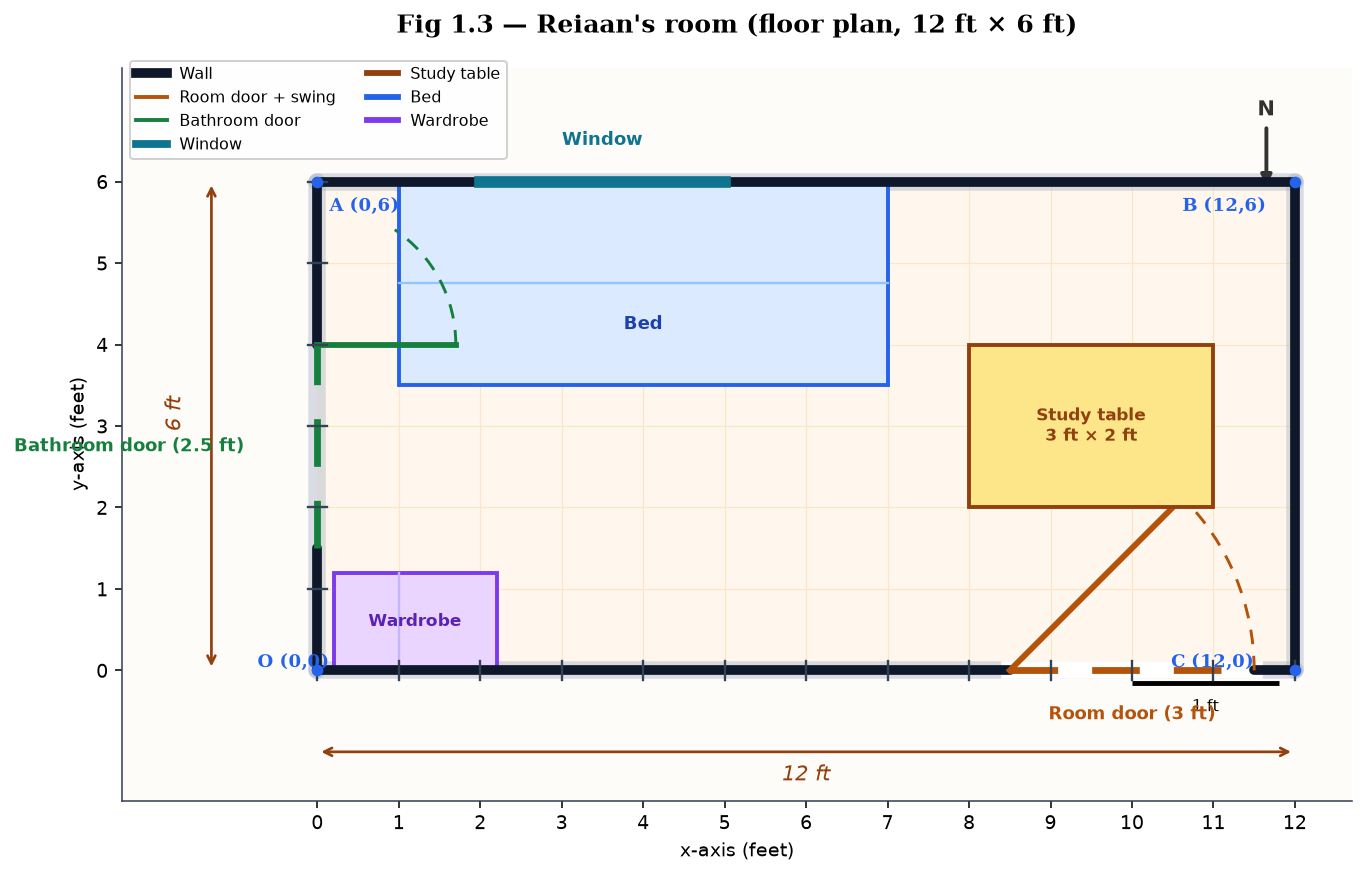

In [3]:
def make_figure(w=12.0, h=6.0, **kw):
    fig, ax = plt.subplots(figsize=(10, 6.2), dpi=140)
    draw_room(ax, w, h, **kw)
    # title
    ax.set_title('Fig 1.3 — Reiaan\'s room (floor plan, 12 ft × 6 ft)',
                 fontsize=13, fontweight='bold', family=SERIF, pad=18)
    # aspect + view bounds
    ax.set_aspect('equal')
    ax.set_xlim(-2.4, w+0.7)
    ax.set_ylim(-1.6, h+1.4)
    ax.set_xticks(range(0, int(w)+1)); ax.set_yticks(range(0, int(h)+1))
    ax.set_xticklabels([str(i) for i in range(int(w)+1)])
    ax.set_yticklabels([str(j) for j in range(int(h)+1)])
    ax.set_xlabel('x-axis (feet)'); ax.set_ylabel('y-axis (feet)')
    ax.spines[:].set_color(AXIS)
    for s in ('top','right'): ax.spines[s].set_visible(False)

    # scale bar + north arrow (nails the 'drafted plan' look)
    ax.plot([w-2.0, w-0.2],[ -0.15,-0.15], color='k', lw=2.5, solid_capstyle='butt')
    ax.text(w-1.1, -0.5, '1 ft', ha='center', fontsize=8)
    ax.annotate('N', xy=(w-0.35, h-0.1), xytext=(w-0.35, h+0.75),
                arrowprops=dict(arrowstyle='-|>', lw=2, color='#333'),
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333')
    # legend
    handles = [
        plt.Line2D([],[],color=WALL,lw=5,label='Wall'),
        plt.Line2D([],[],color=AMBER,lw=2,label='Room door + swing'),
        plt.Line2D([],[],color=GREEN,lw=2,label='Bathroom door'),
        plt.Line2D([],[],color=CYAN,lw=4,label='Window'),
        plt.Line2D([],[],color=WOOD,lw=3,label='Study table'),
        plt.Line2D([],[],color=BLUE,lw=3,label='Bed'),
        plt.Line2D([],[],color=PURPLE,lw=3,label='Wardrobe'),
    ]
    ax.legend(handles=handles, loc='upper left', framealpha=0.9, fontsize=8, ncol=2,
              bbox_to_anchor=(0.0,1.02))
    return fig, ax

fig, ax = make_figure();
plt.tight_layout()
plt.show()

## 4. Interactive exploration

The cells below wrap `draw_room()` in a **manual image** re-render that is rebuilt inside an `ipywidget`. Use the slider to change the room size (the classic 12×6 is the textbook case) and the toggles to:
- switch **emphasis** between the four textbook sub-questions (Q1–Q4) or show all,
- show/hide the **grid**, **furniture**, **labels** and **dimensions**.

In [4]:
import ipywidgets as wg
from IPython.display import display

# build the controls
ctrl = {
    'w'    : wg.FloatSlider(value=12, min=8,  max=16, step=1, description='Width (ft):'),
    'h'    : wg.FloatSlider(value=6,  min=4,  max=10, step=1, description='Height (ft):'),
    'grid' : wg.Checkbox(value=True, description='Show grid'),
    'furn' : wg.Checkbox(value=True, description='Show furniture'),
    'lbl'  : wg.Checkbox(value=True, description='Show labels'),
    'dims' : wg.Checkbox(value=True, description='Show dimensions'),
    'emph' : wg.Dropdown(options=['none', 'q1', 'q2', 'q3', 'q4'], value='none',
                          description='Emphasis:'),
}

out = wg.Output()

def _update(change=None):
    with out:
        out.clear_output(wait=True)
        fig, ax = make_figure(
            ctrl['w'].value, ctrl['h'].value,
            show_grid=ctrl['grid'].value, show_furniture=ctrl['furn'].value,
            show_labels=ctrl['lbl'].value, show_dims=ctrl['dims'].value,
            emph=None if ctrl['emph'].value == 'none' else ctrl['emph'].value)
        # patch title to reflect resized dims
        ax.set_title(f"Fig 1.3 — Reiaan's room (floor plan, "
                     f"{ctrl['w'].value:g} ft × {ctrl['h'].value:g} ft)",
                     fontsize=13, fontweight='bold', family=SERIF, pad=18)
        plt.tight_layout()
        plt.show()

for name in ['w', 'h', 'grid', 'furn', 'lbl', 'dims']:
    ctrl[name].observe(_update, 'value')

ui = wg.VBox([wg.HBox([ctrl['w'], ctrl['h']]),
              wg.HBox([ctrl['grid'], ctrl['furn'], ctrl['lbl'], ctrl['dims']]),
              ctrl['emph']])
display(ui, out)
_update(None)  # initial render

Output()

## 5. Summary

You now have two versions of **Fig 1.3**:

- a **high-resolution static** figure suitable for export (PNG/SVG) and print,
- an **interactive** figure that visualises every sub-question of the exercise (Q1–Q4) from the Ganita Manjari chapter, letting you resize the room and toggle layers.

To export the static figure to a file you can add:

```python
fig.savefig('fig13_room.png', dpi=200, bbox_inches='tight')
```